In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 


os.makedirs('../outputs/images', exist_ok=True)

In [139]:
df = pd.read_csv('../data/raw/data.csv')

In [140]:
df.head()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [141]:
df.drop(columns=['loan_id'], inplace=True)

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0    no_of_dependents          4269 non-null   int64 
 1    education                 4269 non-null   object
 2    self_employed             4269 non-null   object
 3    income_annum              4269 non-null   int64 
 4    loan_amount               4269 non-null   int64 
 5    loan_term                 4269 non-null   int64 
 6    cibil_score               4269 non-null   int64 
 7    residential_assets_value  4269 non-null   int64 
 8    commercial_assets_value   4269 non-null   int64 
 9    luxury_assets_value       4269 non-null   int64 
 10   bank_asset_value          4269 non-null   int64 
 11   loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 400.3+ KB


In [143]:
df.columns = df.columns.str.strip()


df['self_employed'].value_counts(dropna=False)

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [144]:
df['education'].value_counts()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [145]:
df.shape

(4269, 12)

In [146]:
!pip install category_encoders

In [147]:
from category_encoders import TargetEncoder

te = TargetEncoder(cols=['loan_status'])
df['loan_status'] = te.fit_transform(df['loan_status'], df['loan_status'])

In [148]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0.0
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1.0
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1.0
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1.0
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1.0


C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_3512\689132299.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['residential_assets_value'], bins=30, kde=True)


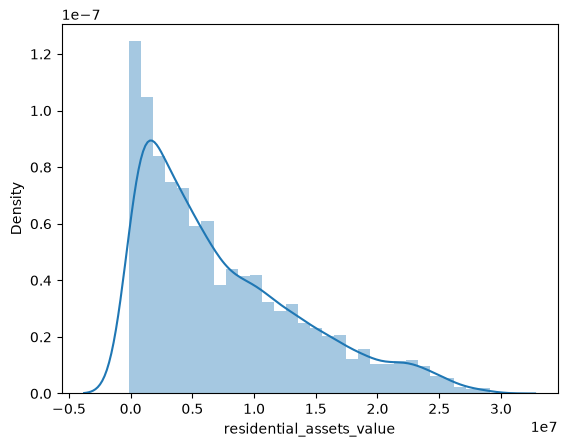

In [149]:
sns.distplot(df['residential_assets_value'], bins=30, kde=True)

plt.savefig('../outputs/images/residential_assets_value_distribution.png', dpi=300, bbox_inches='tight')

In [150]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0.0
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1.0
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1.0
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1.0
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,1.0
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,0.0
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,1.0
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,0.0


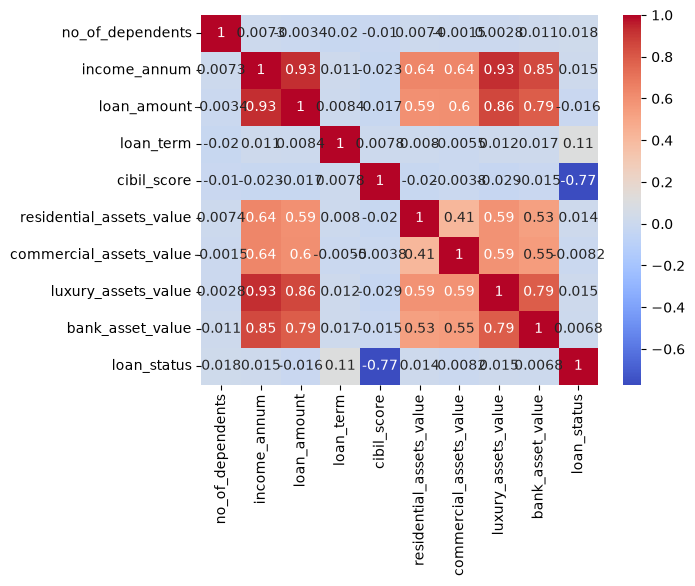

In [151]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.savefig('../outputs/images/correlation_heatmap.png', dpi=300, bbox_inches='tight')

In [152]:
df.corr(numeric_only=True)

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
no_of_dependents,1.000000,0.007266,-0.003366,-0.020111,-0.009998,0.007376,-0.001531,0.002817,0.011163,0.018114
income_annum,0.007266,1.000000,0.927470,0.011488,-0.023034,0.636841,0.640328,0.929145,0.851093,0.015189
loan_amount,-0.003366,0.927470,1.000000,0.008437,-0.017035,0.594596,0.603188,0.860914,0.788122,-0.016150
loan_term,-0.020111,0.011488,0.008437,1.000000,0.007810,0.008016,-0.005478,0.012490,0.017177,0.113036
cibil_score,-0.009998,-0.023034,-0.017035,0.007810,1.000000,-0.019947,-0.003769,-0.028618,-0.015478,-0.770518
residential_assets_value,0.007376,0.636841,0.594596,0.008016,-0.019947,1.000000,0.414786,0.590932,0.527418,0.014367
commercial_assets_value,-0.001531,0.640328,0.603188,-0.005478,-0.003769,0.414786,1.000000,0.591128,0.548576,-0.008246
luxury_assets_value,0.002817,0.929145,0.860914,0.012490,-0.028618,0.590932,0.591128,1.000000,0.788517,0.015465
bank_asset_value,0.011163,0.851093,0.788122,0.017177,-0.015478,0.527418,0.548576,0.788517,1.000000,0.006778
loan_status,0.018114,0.015189,-0.016150,0.113036,-0.770518,0.014367,-0.008246,0.015465,0.006778,1.000000


C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_3512\3854906569.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['commercial_assets_value'], bins=30, kde=True)


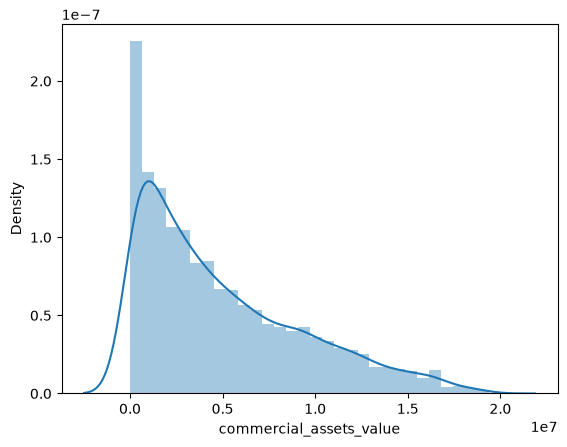

In [153]:
sns.distplot(df['commercial_assets_value'], bins=30, kde=True)

plt.savefig('../outputs/images/commercial_assets_value_distribution.png', dpi=300, bbox_inches='tight')


C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_3512\3410463081.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cibil_score'], bins=30, kde=True)


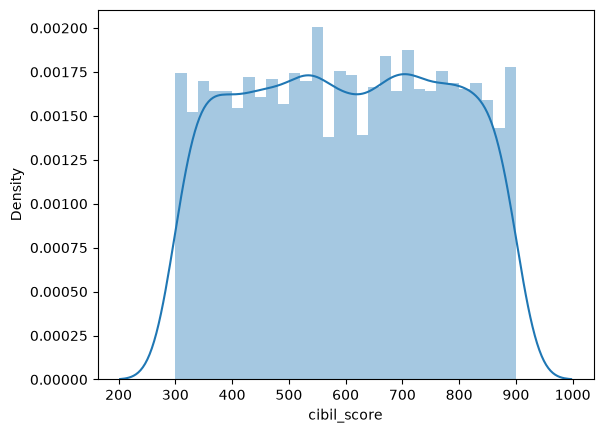

In [154]:
sns.distplot(df['cibil_score'], bins=30, kde=True)

plt.savefig('../outputs/images/cibil_score_distribution.png', dpi=300, bbox_inches='tight')


C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_3512\2869110676.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['loan_amount'], bins=30, kde=True)


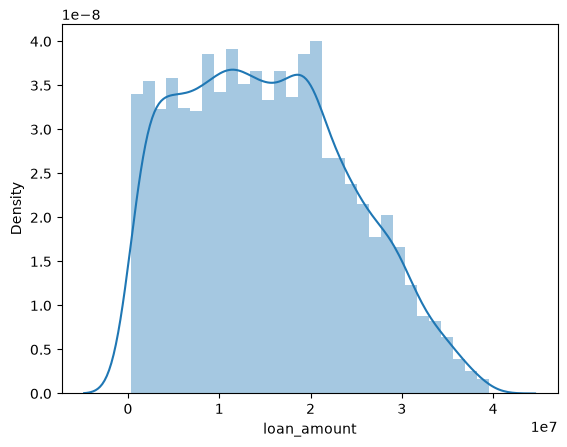

In [155]:
sns.distplot(df['loan_amount'], bins=30, kde=True)

plt.savefig('../outputs/images/loan_amount_distribution.png', dpi=300, bbox_inches='tight')

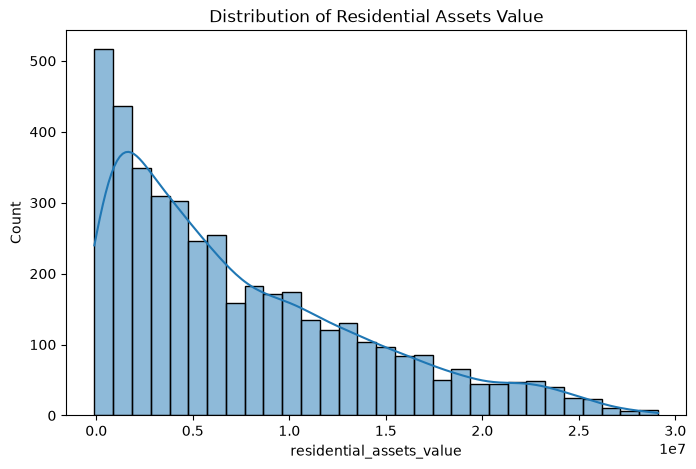

<Figure size 640x480 with 0 Axes>

In [156]:
plt.figure(figsize=(8, 5))
sns.histplot(df['residential_assets_value'], bins=30, kde=True)
plt.title("Distribution of Residential Assets Value")
plt.show()

plt.savefig('../outputs/images/residential_assets_value_distribution_histplot.png', dpi=300, bbox_inches='tight')

In [157]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0.0
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1.0
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1.0
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1.0
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,1.0
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,0.0
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,1.0
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,0.0


C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_3512\807943395.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['loan_amount'], bins=30, kde=True)


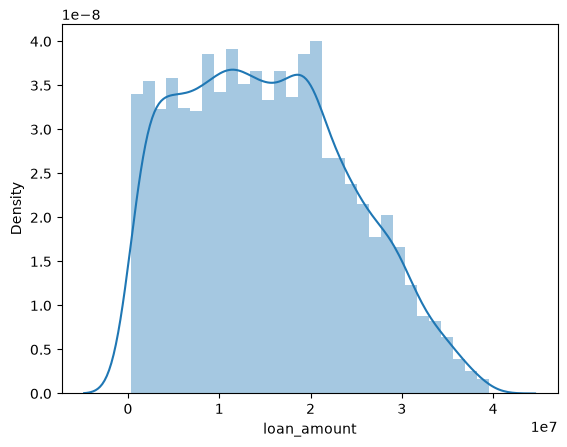

In [158]:
sns.distplot(df['loan_amount'], bins=30, kde=True)
plt.savefig('../outputs/images/loan_amount_distribution.png', dpi=300, bbox_inches='tight')

In [159]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0.0
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1.0
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1.0
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1.0
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1.0


In [160]:
from category_encoders import TargetEncoder

te = TargetEncoder(cols=['education'])
df['education'] = te.fit_transform(df['education'], df['education'])

In [163]:
te = TargetEncoder(cols=['self_employed'])
df['self_employed'] = te.fit_transform(df['self_employed'], df['self_employed'])

In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   no_of_dependents          4269 non-null   int64  
 1   education                 4269 non-null   float64
 2   self_employed             4269 non-null   float64
 3   income_annum              4269 non-null   int64  
 4   loan_amount               4269 non-null   int64  
 5   loan_term                 4269 non-null   int64  
 6   cibil_score               4269 non-null   int64  
 7   residential_assets_value  4269 non-null   int64  
 8   commercial_assets_value   4269 non-null   int64  
 9   luxury_assets_value       4269 non-null   int64  
 10  bank_asset_value          4269 non-null   int64  
 11  loan_status               4269 non-null   float64
dtypes: float64(3), int64(9)
memory usage: 400.3 KB


In [166]:
df.corr()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
no_of_dependents,1.000000,-0.002697,0.000765,0.007266,-0.003366,-0.020111,-0.009998,0.007376,-0.001531,0.002817,0.011163,0.018114
education,-0.002697,1.000000,0.023224,-0.011625,-0.010631,0.008417,0.004649,-0.010930,0.006763,-0.012471,-0.009424,0.004918
self_employed,0.000765,0.023224,1.000000,0.002368,0.001450,0.004107,-0.004866,0.006144,-0.017998,0.004413,-0.000215,-0.000345
income_annum,0.007266,-0.011625,0.002368,1.000000,0.927470,0.011488,-0.023034,0.636841,0.640328,0.929145,0.851093,0.015189
loan_amount,-0.003366,-0.010631,0.001450,0.927470,1.000000,0.008437,-0.017035,0.594596,0.603188,0.860914,0.788122,-0.016150
loan_term,-0.020111,0.008417,0.004107,0.011488,0.008437,1.000000,0.007810,0.008016,-0.005478,0.012490,0.017177,0.113036
cibil_score,-0.009998,0.004649,-0.004866,-0.023034,-0.017035,0.007810,1.000000,-0.019947,-0.003769,-0.028618,-0.015478,-0.770518
residential_assets_value,0.007376,-0.010930,0.006144,0.636841,0.594596,0.008016,-0.019947,1.000000,0.414786,0.590932,0.527418,0.014367
commercial_assets_value,-0.001531,0.006763,-0.017998,0.640328,0.603188,-0.005478,-0.003769,0.414786,1.000000,0.591128,0.548576,-0.008246
luxury_assets_value,0.002817,-0.012471,0.004413,0.929145,0.860914,0.012490,-0.028618,0.590932,0.591128,1.000000,0.788517,0.015465


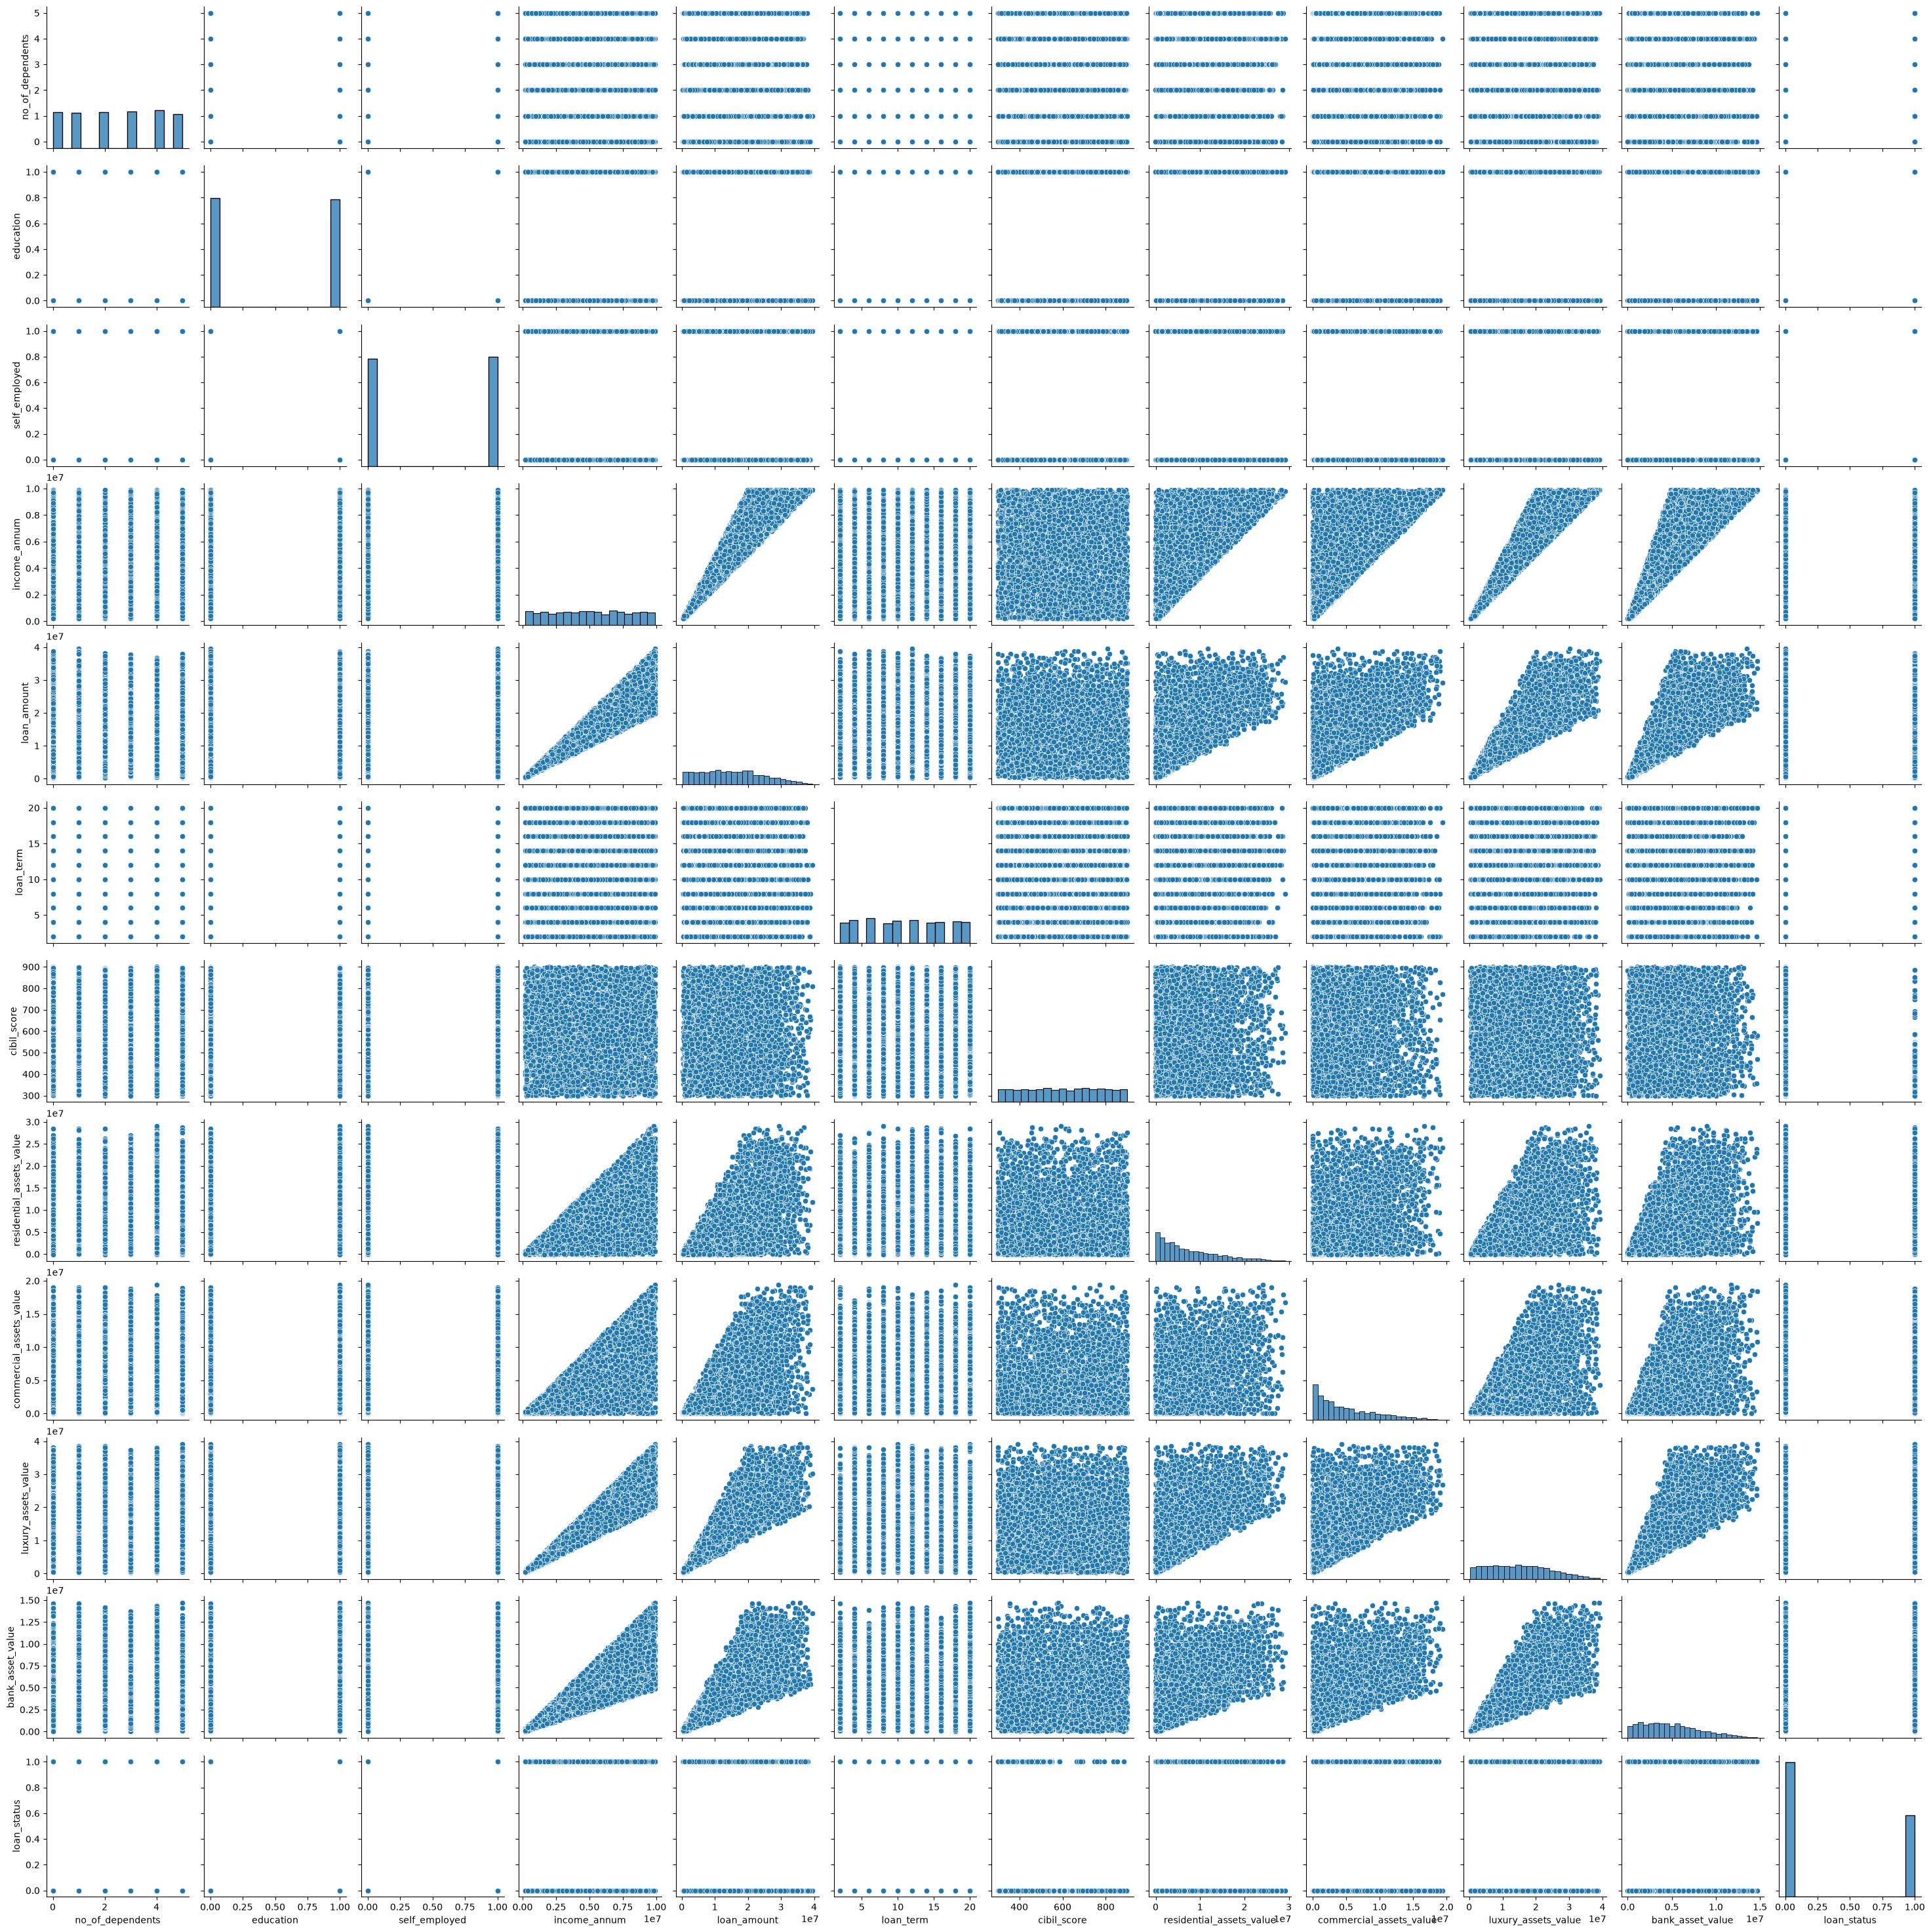

In [167]:
sns.pairplot(df)

plt.savefig('../outputs/images/pairplot.png', dpi=300, bbox_inches='tight')

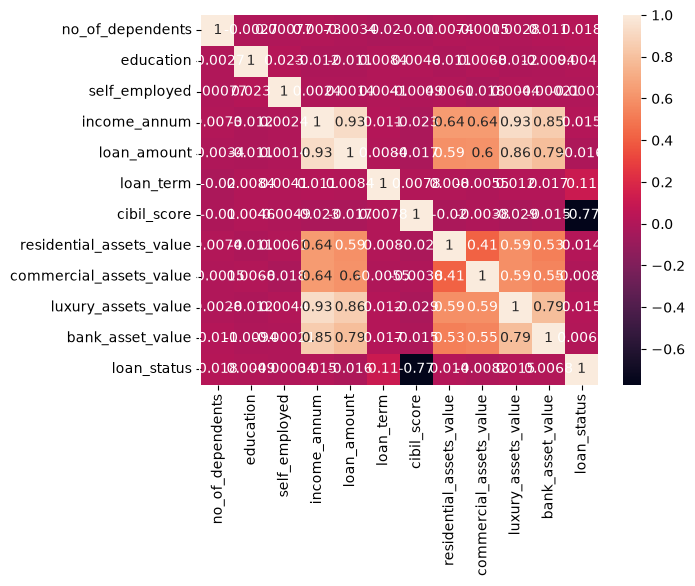

In [168]:
sns.heatmap(df.corr(numeric_only=True),annot=True)


plt.savefig('../outputs/images/correlation_heatmap.png', dpi=300, bbox_inches='tight')

In [170]:
df.to_csv('../data/preprocessed/final.csv',index=True)

In [171]:
df_new = pd.read_csv('../data/preprocessed/final.csv')

In [172]:
df_new

,Unnamed: 0,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,0,2,0.0,0.0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0.0
1,1,0,1.0,1.0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1.0
2,2,3,0.0,0.0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1.0
3,3,3,0.0,0.0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1.0
4,4,5,1.0,1.0,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4264,5,0.0,1.0,1000000,2300000,12,317,2800000,500000,3300000,800000,1.0
4265,4265,0,1.0,1.0,3300000,11300000,20,559,4200000,2900000,11000000,1900000,0.0
4266,4266,2,1.0,0.0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,1.0
4267,4267,1,1.0,0.0,4100000,12800000,8,780,8200000,700000,14100000,5800000,0.0
